# Paso D: Procrustes alignment FR-ES

Alineamos los espacios vectoriales FR y ES usando tokens compartidos como anclas:
1. **Procrustes analysis** — encontrar la rotacion optima que minimiza la distancia entre los espacios
2. **Error de alineacion** por nivel (phoneme, syllable, word)
3. **Nearest-neighbor accuracy** — despues de alinear, que porcentaje de tokens compartidos tienen como vecino mas cercano su equivalente en el otro idioma?
4. **RSA (Representational Similarity Analysis)** — correlacion entre matrices de similitud intra-idioma para las silabas compartidas

In [1]:
import sys
sys.path.insert(0, ".")

from loader import load_all_models, get_vocab, PHONEME_INVENTORY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import procrustes
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import json

models = load_all_models()

# Load shared tokens from paso A
shared_tokens = {}
for level in ("phoneme", "syllable", "word"):
    with open(f"shared_{level}_tokens.json", "r", encoding="utf-8") as f:
        shared_tokens[level] = json.load(f)

print("Models and shared tokens loaded.")
for level in ("phoneme", "syllable", "word"):
    print(f"  {level}: {len(shared_tokens[level])} shared tokens")

Models and shared tokens loaded.
  phoneme: 20 shared tokens
  syllable: 1497 shared tokens
  word: 6827 shared tokens


## 1. Procrustes alignment: error de alineacion por nivel

Procrustes encuentra la rotacion/reflexion optima W tal que ||ES_shared @ W - FR_shared||² es minima. El disparity (error normalizado) indica que tan bien se alinean los espacios: 0 = identicos, 1 = ortogonales.

In [2]:
def get_aligned_matrices(model_es, model_fr, tokens):
    """Get paired vector matrices for shared tokens."""
    es_vecs = np.array([model_es.wv[t] for t in tokens])
    fr_vecs = np.array([model_fr.wv[t] for t in tokens])
    return es_vecs, fr_vecs


def orthogonal_procrustes(source, target):
    """Compute optimal orthogonal mapping from source to target.
    
    Returns W (rotation matrix) and disparity.
    Uses SVD: W = V @ U^T where U S V^T = SVD(target^T @ source)
    """
    # Center
    source_c = source - source.mean(axis=0)
    target_c = target - target.mean(axis=0)
    
    # Normalize
    source_n = source_c / np.linalg.norm(source_c)
    target_n = target_c / np.linalg.norm(target_c)
    
    # SVD
    M = target_n.T @ source_n
    U, S, Vt = np.linalg.svd(M)
    W = U @ Vt
    
    # Disparity (Frobenius norm of residuals, squared)
    aligned = source_n @ W
    disparity = np.sum((aligned - target_n) ** 2)
    
    return W, disparity, source_c, target_c


procrustes_results = []

for level in ("phoneme", "syllable", "word"):
    tokens = shared_tokens[level]
    es_vecs, fr_vecs = get_aligned_matrices(models[level]["es"], models[level]["fr"], tokens)
    
    # scipy.spatial.procrustes (standardized)
    mtx1, mtx2, disparity = procrustes(es_vecs, fr_vecs)
    
    # Also compute our own for the rotation matrix
    W, disp_custom, es_c, fr_c = orthogonal_procrustes(es_vecs, fr_vecs)
    
    procrustes_results.append({
        "Nivel": level,
        "N anchors": len(tokens),
        "Disparity (scipy)": disparity,
        "Disparity (custom)": disp_custom,
    })

proc_df = pd.DataFrame(procrustes_results)
proc_df.round(4)

,Nivel,N anchors,Disparity (scipy),Disparity (custom)
0,phoneme,20,0.1208,2.0634
1,syllable,1497,0.8786,1.9875
2,word,6827,0.7073,1.9508


## 2. Nearest-neighbor accuracy post-alignment

Despues de alinear ES hacia FR usando la rotacion de Procrustes, para cada token compartido en ES-alineado, verificamos si su vecino mas cercano en FR es el token correcto (el mismo token). P@1 = precision at 1, P@5 = el correcto esta entre los 5 mas cercanos.

In [3]:
nn_results = []

for level in ("phoneme", "syllable", "word"):
    tokens = shared_tokens[level]
    es_vecs, fr_vecs = get_aligned_matrices(models[level]["es"], models[level]["fr"], tokens)
    
    # Compute Procrustes rotation
    W, _, es_c, fr_c = orthogonal_procrustes(es_vecs, fr_vecs)
    
    # Align ES to FR space
    es_aligned = (es_vecs - es_vecs.mean(axis=0)) @ W
    fr_centered = fr_vecs - fr_vecs.mean(axis=0)
    
    # Cosine similarity matrix: each ES-aligned vs all FR
    sim_matrix = cosine_similarity(es_aligned, fr_centered)
    
    # For each ES token, find nearest FR tokens
    p_at_1 = 0
    p_at_5 = 0
    p_at_10 = 0
    
    for i in range(len(tokens)):
        ranked = np.argsort(-sim_matrix[i])  # descending similarity
        if ranked[0] == i:
            p_at_1 += 1
        if i in ranked[:5]:
            p_at_5 += 1
        if i in ranked[:10]:
            p_at_10 += 1
    
    n = len(tokens)
    nn_results.append({
        "Nivel": level,
        "N tokens": n,
        "P@1": p_at_1 / n,
        "P@5": p_at_5 / n,
        "P@10": p_at_10 / n,
        "Random baseline P@1": 1 / n,
    })

nn_df = pd.DataFrame(nn_results)
nn_df.round(4)

,Nivel,N tokens,P@1,P@5,P@10,Random baseline P@1
0,phoneme,20,0.0000,0.2500,0.4500,0.0500
1,syllable,1497,0.0013,0.0047,0.0087,0.0007
2,word,6827,0.0004,0.0023,0.0042,0.0001


## 3. Visualizacion: tokens compartidos en el espacio alineado

Proyectamos los vectores ES-alineados y FR a 2D con t-SNE para ver visualmente que tan cerca caen los mismos tokens en ambos idiomas.

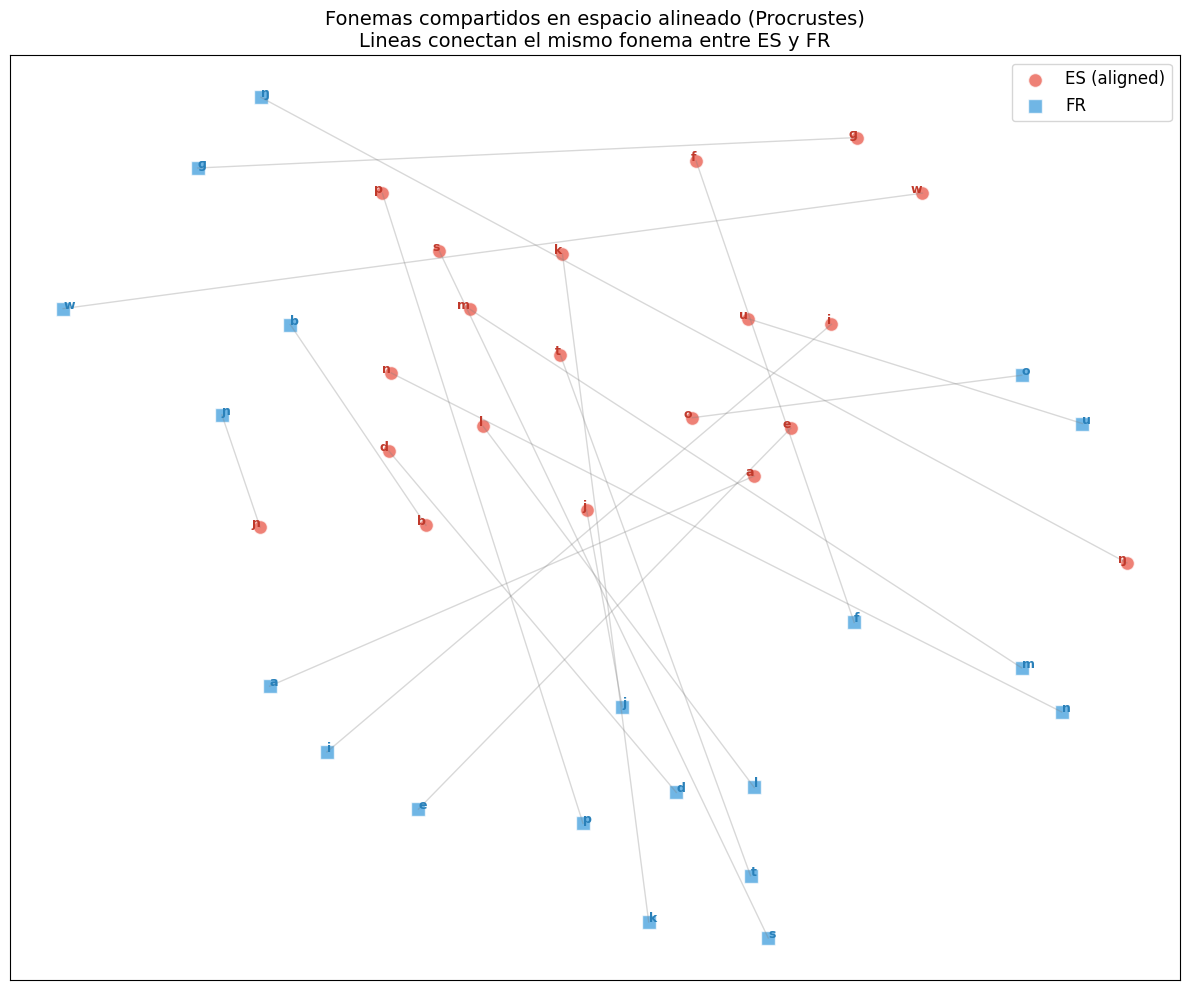

In [4]:
# Phoneme-level alignment visualization (small enough to label all)
tokens = shared_tokens["phoneme"]
es_vecs, fr_vecs = get_aligned_matrices(models["phoneme"]["es"], models["phoneme"]["fr"], tokens)
W, _, _, _ = orthogonal_procrustes(es_vecs, fr_vecs)

es_aligned = (es_vecs - es_vecs.mean(axis=0)) @ W
fr_centered = fr_vecs - fr_vecs.mean(axis=0)

# Stack both and do t-SNE together
combined = np.vstack([es_aligned, fr_centered])
tsne = TSNE(n_components=2, perplexity=min(8, len(tokens)-1), random_state=42, max_iter=2000)
coords = tsne.fit_transform(combined)

es_coords = coords[:len(tokens)]
fr_coords = coords[len(tokens):]

fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(es_coords[:, 0], es_coords[:, 1], c="#e74c3c", s=100, alpha=0.7, label="ES (aligned)", marker="o", edgecolors="white")
ax.scatter(fr_coords[:, 0], fr_coords[:, 1], c="#3498db", s=100, alpha=0.7, label="FR", marker="s", edgecolors="white")

# Draw lines connecting same token across languages
for i, t in enumerate(tokens):
    ax.plot([es_coords[i, 0], fr_coords[i, 0]], [es_coords[i, 1], fr_coords[i, 1]],
            color="gray", alpha=0.3, linewidth=1)
    ax.annotate(t, (es_coords[i, 0], es_coords[i, 1]), fontsize=9, color="#c0392b",
               ha="right", fontweight="bold")
    ax.annotate(t, (fr_coords[i, 0], fr_coords[i, 1]), fontsize=9, color="#2980b9",
               ha="left", fontweight="bold")

ax.legend(fontsize=12)
ax.set_title("Fonemas compartidos en espacio alineado (Procrustes)\nLineas conectan el mismo fonema entre ES y FR",
            fontsize=14)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("procrustes_phonemes.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. RSA (Representational Similarity Analysis) — silabas compartidas

Construimos la matriz de similitud coseno entre todas las silabas compartidas **dentro** de cada idioma, y luego correlacionamos esas matrices. Alta correlacion = la estructura relacional (que silabas son similares entre si) se conserva entre idiomas.

Este es el test mas fuerte de universalidad fonestemica: no depende de la alineacion, sino de las relaciones internas.

In [5]:
from scipy.spatial.distance import squareform

rsa_results = []

for level in ("phoneme", "syllable", "word"):
    tokens = shared_tokens[level]
    es_vecs = np.array([models[level]["es"].wv[t] for t in tokens])
    fr_vecs = np.array([models[level]["fr"].wv[t] for t in tokens])
    
    # Compute pairwise cosine similarity matrices
    sim_es = cosine_similarity(es_vecs)
    sim_fr = cosine_similarity(fr_vecs)
    
    # Extract upper triangle (exclude diagonal)
    triu_idx = np.triu_indices(len(tokens), k=1)
    es_upper = sim_es[triu_idx]
    fr_upper = sim_fr[triu_idx]
    
    # Correlate
    rho_spearman, p_spearman = spearmanr(es_upper, fr_upper)
    rho_pearson, p_pearson = pearsonr(es_upper, fr_upper)
    
    rsa_results.append({
        "Nivel": level,
        "N tokens": len(tokens),
        "N pairs": len(es_upper),
        "Spearman rho": rho_spearman,
        "Spearman p": p_spearman,
        "Pearson r": rho_pearson,
        "Pearson p": p_pearson,
    })

rsa_df = pd.DataFrame(rsa_results)
rsa_df.round(6)

,Nivel,N tokens,N pairs,Spearman rho,Spearman p,Pearson r,Pearson p
0,phoneme,20,190,0.826948,0.0,0.867248,0.0
1,syllable,1497,1119756,0.215216,0.0,0.234907,0.0
2,word,6827,23300551,0.566480,0.0,0.615889,0.0


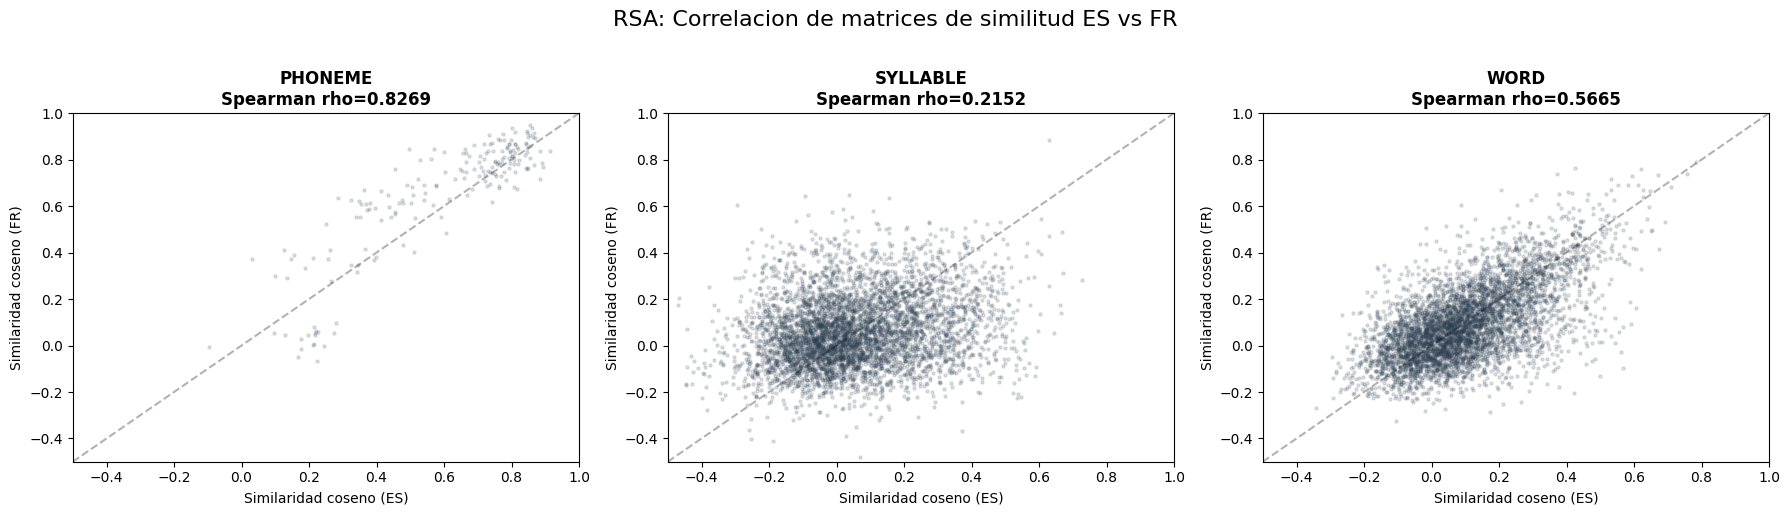

In [6]:
# Visualize RSA: scatter plot of pairwise similarities ES vs FR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    tokens = shared_tokens[level]
    es_vecs = np.array([models[level]["es"].wv[t] for t in tokens])
    fr_vecs = np.array([models[level]["fr"].wv[t] for t in tokens])
    
    sim_es = cosine_similarity(es_vecs)
    sim_fr = cosine_similarity(fr_vecs)
    
    triu_idx = np.triu_indices(len(tokens), k=1)
    es_upper = sim_es[triu_idx]
    fr_upper = sim_fr[triu_idx]
    
    # Subsample for visualization if too many pairs
    if len(es_upper) > 5000:
        rng = np.random.RandomState(42)
        sample = rng.choice(len(es_upper), 5000, replace=False)
        es_plot, fr_plot = es_upper[sample], fr_upper[sample]
    else:
        es_plot, fr_plot = es_upper, fr_upper
    
    ax.scatter(es_plot, fr_plot, alpha=0.15, s=5, c="#2c3e50")
    
    rho = rsa_results[idx]["Spearman rho"]
    ax.set_xlabel("Similaridad coseno (ES)")
    ax.set_ylabel("Similaridad coseno (FR)")
    ax.set_title(f"{level.upper()}\nSpearman rho={rho:.4f}", fontsize=12, fontweight="bold")
    
    # Diagonal reference
    lims = [-0.5, 1.0]
    ax.plot(lims, lims, 'k--', alpha=0.3)
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle("RSA: Correlacion de matrices de similitud ES vs FR", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("rsa_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. RSA con test de Mantel (permutacion)

El test de Mantel verifica si la correlacion entre las matrices de similitud es significativa, controlando por las dependencias entre pares.

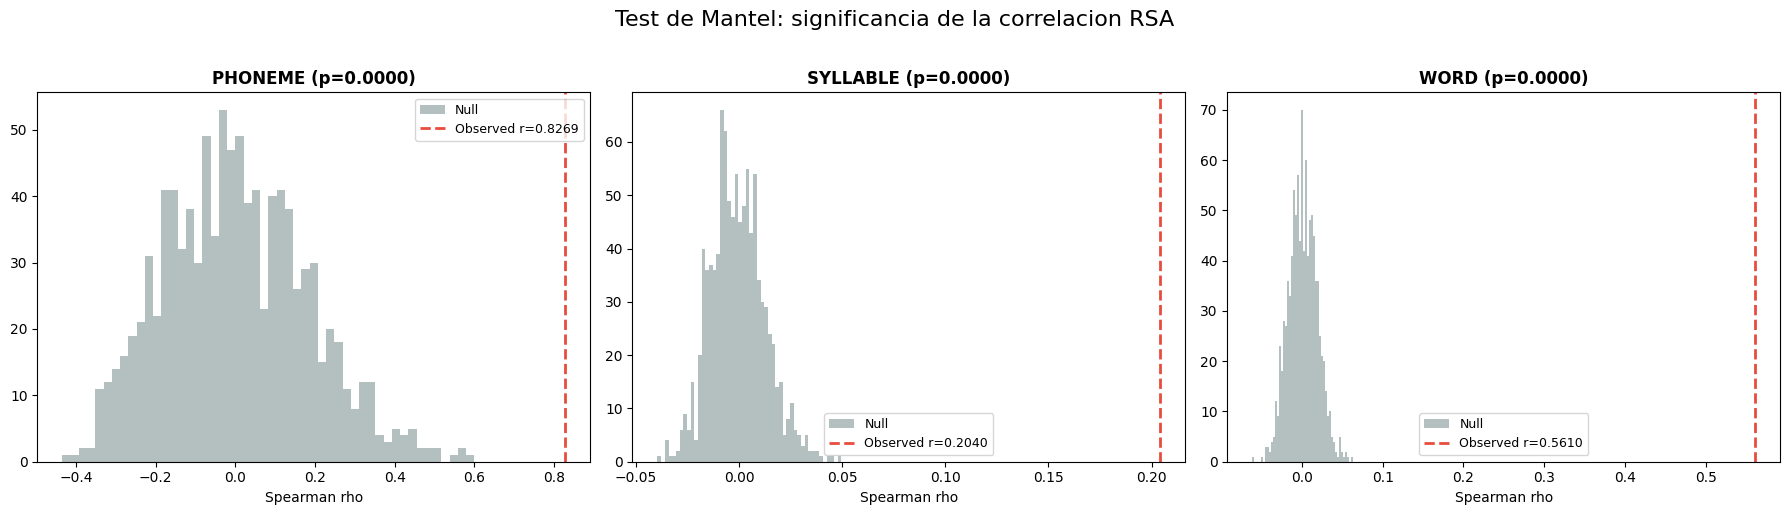

,Nivel,N tokens,Mantel r,p-value
0,phoneme,20,0.8269,0.0
1,syllable,500,0.2040,0.0
2,word,500,0.5610,0.0


In [7]:
def mantel_test(mat_a, mat_b, n_perms=1000, seed=42):
    """Mantel test: correlate two distance/similarity matrices with permutation significance."""
    n = mat_a.shape[0]
    triu = np.triu_indices(n, k=1)
    
    a_upper = mat_a[triu]
    b_upper = mat_b[triu]
    
    observed_r, _ = spearmanr(a_upper, b_upper)
    
    rng = np.random.RandomState(seed)
    null_rs = []
    for _ in range(n_perms):
        perm = rng.permutation(n)
        b_perm = mat_b[np.ix_(perm, perm)]
        b_upper_perm = b_perm[triu]
        r_perm, _ = spearmanr(a_upper, b_upper_perm)
        null_rs.append(r_perm)
    
    null_rs = np.array(null_rs)
    p_value = (null_rs >= observed_r).mean()
    
    return observed_r, p_value, null_rs


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mantel_results = []
for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    tokens = shared_tokens[level]
    
    # For word level, sample to keep Mantel tractable
    if len(tokens) > 500:
        rng = np.random.RandomState(42)
        sample_idx = rng.choice(len(tokens), 500, replace=False)
        tokens_sample = [tokens[i] for i in sample_idx]
    else:
        tokens_sample = tokens
    
    es_vecs = np.array([models[level]["es"].wv[t] for t in tokens_sample])
    fr_vecs = np.array([models[level]["fr"].wv[t] for t in tokens_sample])
    
    sim_es = cosine_similarity(es_vecs)
    sim_fr = cosine_similarity(fr_vecs)
    
    obs_r, p_val, null_rs = mantel_test(sim_es, sim_fr, n_perms=1000)
    
    mantel_results.append({
        "Nivel": level,
        "N tokens": len(tokens_sample),
        "Mantel r": obs_r,
        "p-value": p_val,
    })
    
    ax.hist(null_rs, bins=50, alpha=0.7, color="#95a5a6", label="Null")
    ax.axvline(x=obs_r, color="#e74c3c", linewidth=2, linestyle="--",
              label=f"Observed r={obs_r:.4f}")
    ax.set_xlabel("Spearman rho")
    ax.set_title(f"{level.upper()} (p={p_val:.4f})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Test de Mantel: significancia de la correlacion RSA", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("mantel_test.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(mantel_results).round(4)

## 6. Resumen comparativo: disparity, P@1, RSA por nivel

In [8]:
# Merge all results into one summary
summary = proc_df[["Nivel", "Disparity (scipy)"]].copy()
summary = summary.merge(nn_df[["Nivel", "P@1", "P@5", "P@10"]], on="Nivel")
summary = summary.merge(rsa_df[["Nivel", "Spearman rho", "Spearman p"]], on="Nivel")

summary.columns = ["Nivel", "Procrustes Disparity", "P@1", "P@5", "P@10",
                    "RSA Spearman rho", "RSA p-value"]
summary.round(4)

,Nivel,Procrustes Disparity,P@1,P@5,P@10,RSA Spearman rho,RSA p-value
0,phoneme,0.1208,0.0000,0.2500,0.4500,0.8269,0.0
1,syllable,0.8786,0.0013,0.0047,0.0087,0.2152,0.0
2,word,0.7073,0.0004,0.0023,0.0042,0.5665,0.0


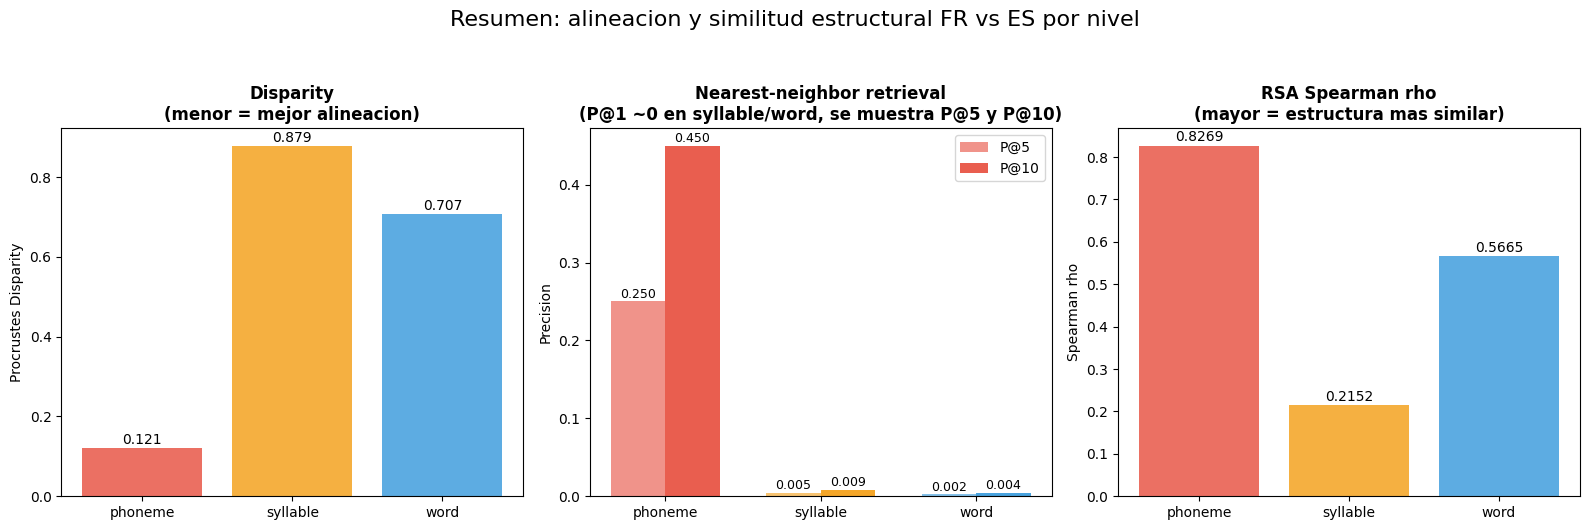

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

levels = ["phoneme", "syllable", "word"]
colors = ["#e74c3c", "#f39c12", "#3498db"]

# Disparity (lower = better alignment)
ax = axes[0]
vals = [summary[summary["Nivel"] == lv]["Procrustes Disparity"].values[0] for lv in levels]
bars = ax.bar(levels, vals, color=colors, alpha=0.8)
ax.set_ylabel("Procrustes Disparity")
ax.set_title("Disparity\n(menor = mejor alineacion)", fontweight="bold")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f"{v:.3f}", ha="center")

# P@5 and P@10 (P@1 is ~0, so show P@5 and P@10 instead)
ax = axes[1]
p5_vals = [summary[summary["Nivel"] == lv]["P@5"].values[0] for lv in levels]
p10_vals = [summary[summary["Nivel"] == lv]["P@10"].values[0] for lv in levels]
x = np.arange(len(levels))
w = 0.35
bars1 = ax.bar(x - w/2, p5_vals, w, color=[c for c in colors], alpha=0.6, label="P@5")
bars2 = ax.bar(x + w/2, p10_vals, w, color=[c for c in colors], alpha=0.9, label="P@10")
ax.set_xticks(x); ax.set_xticklabels(levels)
ax.set_ylabel("Precision")
ax.set_title("Nearest-neighbor retrieval\n(P@1 ~0 en syllable/word, se muestra P@5 y P@10)", fontweight="bold")
ax.legend()
for bar, v in zip(bars1, p5_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, f"{v:.3f}", ha="center", fontsize=9)
for bar, v in zip(bars2, p10_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, f"{v:.3f}", ha="center", fontsize=9)

# RSA rho (higher = more similar structure)
ax = axes[2]
vals = [summary[summary["Nivel"] == lv]["RSA Spearman rho"].values[0] for lv in levels]
bars = ax.bar(levels, vals, color=colors, alpha=0.8)
ax.set_ylabel("Spearman rho")
ax.set_title("RSA Spearman rho\n(mayor = estructura mas similar)", fontweight="bold")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f"{v:.4f}", ha="center")

plt.suptitle("Resumen: alineacion y similitud estructural FR vs ES por nivel", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig("summary_alignment.png", dpi=150, bbox_inches="tight")
plt.show()